# 01 — モジュール形状追跡

ViT の各モジュールを通過するたびにテンソルの**形状**と**値**がどう変わるかを
1 ステップずつ追いかける。学習済みモデルを使うことで「意味のある表現」を観察できる。

| ステップ | 形状 | 概要 |
|---|---|---|
| 入力画像 | `(1, 3, 32, 32)` | CIFAR-10 |
| PatchEmbedding | `(1, 64, 256)` | 64 パッチ × 256 次元 |
| CLS token 付加 | `(1, 65, 256)` | 先頭に 1 分類トークン |
| Positional Embedding | `(1, 65, 256)` | 加算なので形は不変 |
| Transformer ×6 | `(1, 65, 256)` | 形は不変、内容が変化 |
| CLS 取り出し | `(256,)` | 分類用の代表ベクトル |
| Head | `(10,)` | クラス確率 |


In [1]:
import sys, pathlib
# notebooks/ の親（vit/）を Python パスに追加して vit パッケージを import できるようにする
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib
import matplotlib.font_manager as _fm
# macOS 標準の日本語フォントを自動検出して設定（なければ DejaVu にフォールバック）
_jp = next((f.name for f in _fm.fontManager.ttflist if "Hiragino Sans" == f.name), None)
if _jp:
    matplotlib.rcParams["font.family"] = _jp
matplotlib.rcParams["axes.unicode_minus"] = False  # マイナス記号の文字化け防止

import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from viz_utils import (
    CIFAR10_CLASSES, CIFAR10_MEAN, CIFAR10_STD,
    denormalize, to_hwc, show_image, show_patches,
    overlay_attention, attention_rollout,
)
from vit import ViT

MODEL_PATH  = "../best_vit.pth"
DATA_ROOT   = "../data"
PATCH_SIZE  = 4
EMBED_DIM   = 256
DEPTH       = 6
NUM_HEADS   = 8
MLP_DIM     = 512
model = ViT(
    image_size=32, patch_size=PATCH_SIZE, num_classes=10,
    embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM, dropout=0.1, emb_dropout=0.1,
)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print(f"モデルロード完了  パラメータ数: {model.num_parameters():,}")


モデルロード完了  パラメータ数: 3,190,634


## テスト画像をロード

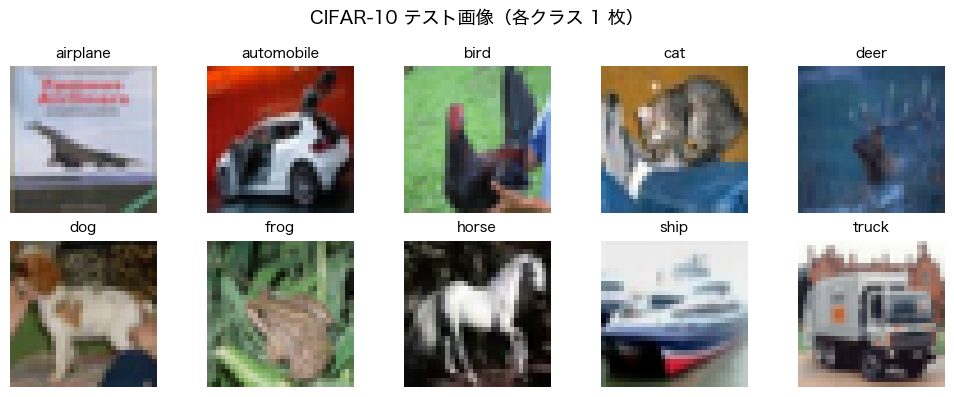

In [2]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_ds = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=False, transform=transform
)

# クラスごとに 1 枚ずつ集める
by_class: dict[int, torch.Tensor] = {}
for img, label in test_ds:
    if label not in by_class:
        by_class[label] = img
    if len(by_class) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for cls_id, ax in zip(range(10), axes.flat):
    show_image(by_class[cls_id], ax=ax, title=CIFAR10_CLASSES[cls_id])
fig.suptitle("CIFAR-10 テスト画像（各クラス 1 枚）", fontsize=13)
plt.tight_layout()
plt.show()


## ① Patch Embedding

32×32 の画像を **4×4 のパッチに分割**し、各パッチ（=48 次元ベクトル）を
線形射影で **256 次元**に変換する。
64 枚のパッチ → 64 個の 256 次元ベクトル列。


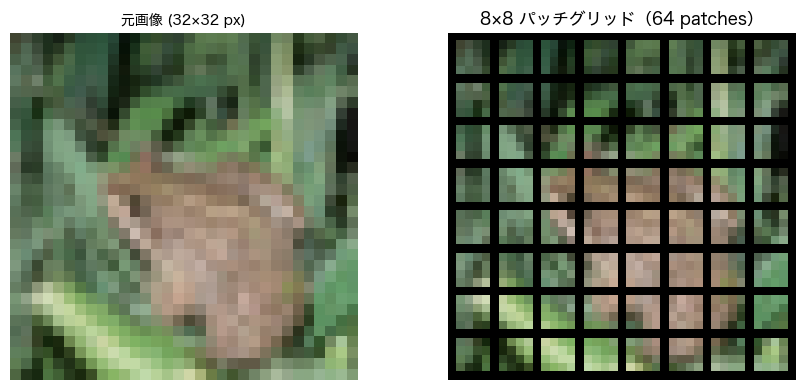

1 パッチのサイズ: 4×4×3 = 48 次元  →  線形射影  →  256 次元


In [3]:
# 「frog」を使って追ってみる
img = by_class[6]   # frog

# 元画像とパッチグリッドを並べて表示
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_image(img, ax=axes[0], title="元画像 (32×32 px)")

# パッチを 8×8 グリッドに並べて表示
import torchvision.utils as vutils
from einops import rearrange

patches = rearrange(
    denormalize(img),
    "c (h p1) (w p2) -> (h w) c p1 p2",
    p1=PATCH_SIZE, p2=PATCH_SIZE,
)  # (64, 3, 4, 4)

grid = vutils.make_grid(patches, nrow=8, padding=1, normalize=False)
axes[1].imshow(grid.permute(1, 2, 0).numpy(), interpolation="nearest")
axes[1].set_title(f"8×8 パッチグリッド（{patches.shape[0]} patches）")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"1 パッチのサイズ: {PATCH_SIZE}×{PATCH_SIZE}×3 = {PATCH_SIZE*PATCH_SIZE*3} 次元  →  線形射影  →  {EMBED_DIM} 次元")


In [4]:
# PatchEmbedding の入出力形状を確認
with torch.no_grad():
    x_raw = img.unsqueeze(0)              # (1, 3, 32, 32)
    x_emb = model.patch_embed(x_raw)     # (1, 64, 256)

print("─── PatchEmbedding 形状変化 ─────────────────────────────────")
print(f"  入力 : {tuple(x_raw.shape)}        (B, C, H, W)")
print(f"  出力 : {tuple(x_emb.shape)}  (B, N_patches, embed_dim)")
print()
print("各パッチベクトルの統計:")
print(f"  mean = {x_emb.mean():.4f},  std = {x_emb.std():.4f}")
print(f"  norm per patch (mean): {x_emb[0].norm(dim=-1).mean():.4f}")


─── PatchEmbedding 形状変化 ─────────────────────────────────
  入力 : (1, 3, 32, 32)        (B, C, H, W)
  出力 : (1, 64, 256)  (B, N_patches, embed_dim)

各パッチベクトルの統計:
  mean = -0.0028,  std = 0.3412
  norm per patch (mean): 5.4030


## ② CLS Token 付加

BERT の `[CLS]` と同じ発想。
学習可能な **1 ベクトル**をシーケンスの先頭に付加する。
このトークンが Transformer を通じて画像全体の情報を集約し、最終的に分類に使われる。


─── CLS token 付加 ──────────────────────────────────────────
  パッチ列     : (1, 64, 256)
  CLS token   : (1, 1, 256)
  結合後       : (1, 65, 256)  ← index 0 が CLS


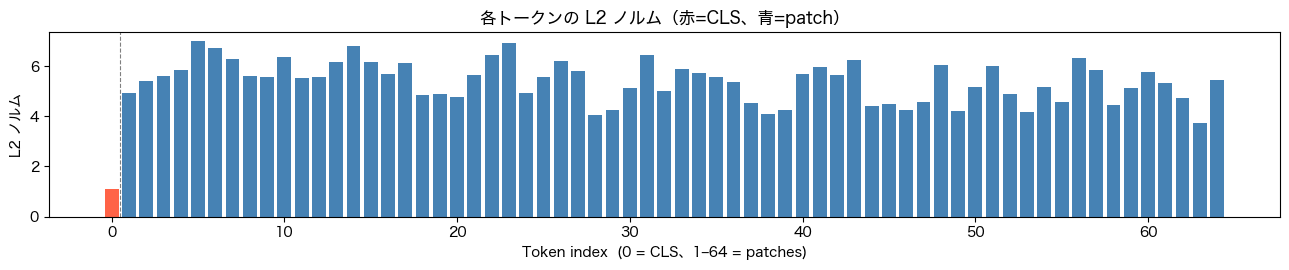

In [5]:
with torch.no_grad():
    cls = model.cls_token.expand(1, -1, -1)       # (1,  1, 256)
    x_with_cls = torch.cat([cls, x_emb], dim=1)  # (1, 65, 256)

print("─── CLS token 付加 ──────────────────────────────────────────")
print(f"  パッチ列     : {tuple(x_emb.shape)}")
print(f"  CLS token   : {tuple(cls.shape)}")
print(f"  結合後       : {tuple(x_with_cls.shape)}  ← index 0 が CLS")

# 全 65 トークンのノルムを棒グラフで可視化
norms = x_with_cls[0].norm(dim=-1).numpy()   # (65,)
colors = ["tomato"] + ["steelblue"] * 64

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.bar(range(65), norms, color=colors, width=0.8)
ax.set_xlabel("Token index  (0 = CLS、1–64 = patches)")
ax.set_ylabel("L2 ノルム")
ax.set_title("各トークンの L2 ノルム（赤=CLS、青=patch）")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()


## ③ Positional Embedding

全 65 トークンに「自分はシーケンスの何番目か」という位置情報を**加算**する。
重みは学習によって獲得される（ViT は固定 sin/cos ではなく学習可能）。


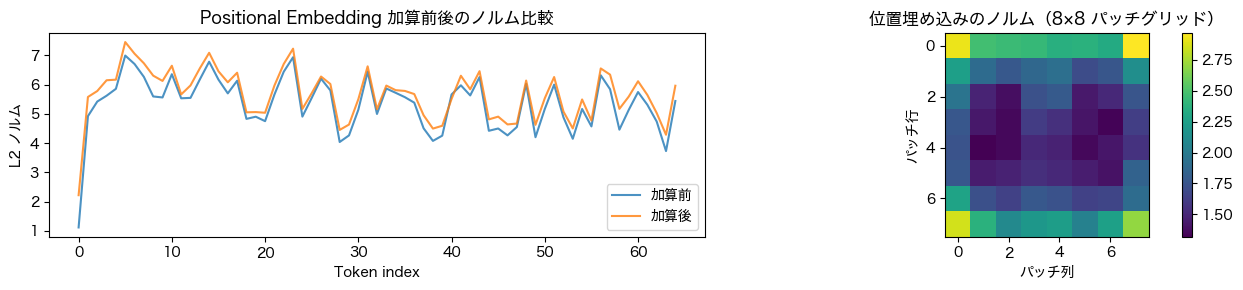

In [6]:
with torch.no_grad():
    x_before_pos = x_with_cls.clone()
    x_after_pos  = x_with_cls + model.pos_embed   # (1, 65, 256)

# 位置埋め込みそのもののノルム（各トークンへの「追加情報量」）
pos_norms = model.pos_embed[0].detach().norm(dim=-1).numpy()   # (65,)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

# 加算前後のノルム比較
axes[0].plot(x_before_pos[0].norm(dim=-1).numpy(), label="加算前", alpha=0.8)
axes[0].plot(x_after_pos [0].norm(dim=-1).numpy(), label="加算後", alpha=0.8)
axes[0].set_xlabel("Token index")
axes[0].set_ylabel("L2 ノルム")
axes[0].set_title("Positional Embedding 加算前後のノルム比較")
axes[0].legend()

# pos_embed 自体のノルムを 8×8 マップとして表示（パッチ部分のみ）
pos_patch_norms = pos_norms[1:].reshape(8, 8)  # CLS を除いた 64 パッチ分
im = axes[1].imshow(pos_patch_norms, cmap="viridis", interpolation="nearest")
axes[1].set_title("位置埋め込みのノルム（8×8 パッチグリッド）")
axes[1].set_xlabel("パッチ列")
axes[1].set_ylabel("パッチ行")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()


## ④ Transformer Encoder（6 層）

各層で Self-Attention + FFN を適用し、パッチ間の依存関係を学習する。
CLS トークンのノルムを層ごとにプロットして、表現がどう成長するかを観察する。


  Block 0:  CLS norm = 36.2843  |  patch mean norm = 61.8219
  Block 1:  CLS norm = 64.0743  |  patch mean norm = 74.5402
  Block 2:  CLS norm = 81.2057  |  patch mean norm = 83.8782
  Block 3:  CLS norm = 104.1580  |  patch mean norm = 86.7509
  Block 4:  CLS norm = 110.7481  |  patch mean norm = 88.4862
  Block 5:  CLS norm = 159.3610  |  patch mean norm = 98.7050


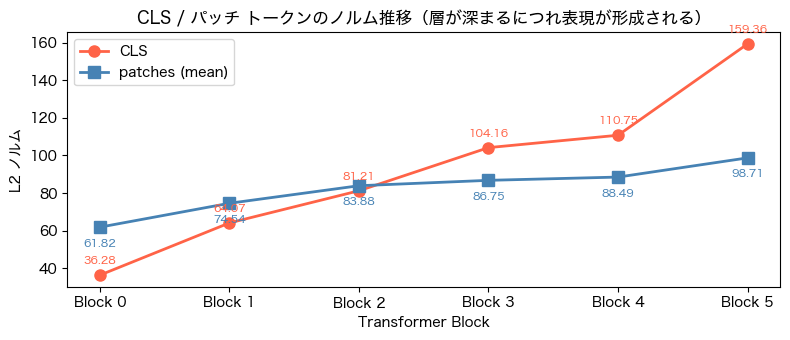

In [7]:
with torch.no_grad():
    x = x_after_pos.clone()
    x = model.emb_dropout(x)

    cls_norms   = []   # CLS ノルムの推移
    patch_norms = []   # パッチ平均ノルムの推移

    for i, block in enumerate(model.transformer):
        x = block(x)
        cn = x[0, 0].norm().item()
        pn = x[0, 1:].norm(dim=-1).mean().item()
        cls_norms.append(cn)
        patch_norms.append(pn)
        print(f"  Block {i}:  CLS norm = {cn:.4f}  |  patch mean norm = {pn:.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(DEPTH), cls_norms,   "o-", color="tomato",    lw=2, ms=8, label="CLS")
ax.plot(range(DEPTH), patch_norms, "s-", color="steelblue", lw=2, ms=8, label="patches (mean)")
for i, (c, p) in enumerate(zip(cls_norms, patch_norms)):
    ax.annotate(f"{c:.2f}", (i, c), xytext=(0, 8),  textcoords="offset points",
                ha="center", fontsize=8, color="tomato")
    ax.annotate(f"{p:.2f}", (i, p), xytext=(0, -14), textcoords="offset points",
                ha="center", fontsize=8, color="steelblue")
ax.set_xlabel("Transformer Block")
ax.set_ylabel("L2 ノルム")
ax.set_title("CLS / パッチ トークンのノルム推移（層が深まるにつれ表現が形成される）")
ax.set_xticks(range(DEPTH))
ax.set_xticklabels([f"Block {i}" for i in range(DEPTH)])
ax.legend()
plt.tight_layout()
plt.show()


## ⑤ Classification Head

Transformer 出力の **CLS トークン**（index=0）だけを取り出して
Linear(256 → 10) → Softmax でクラス確率を出力する。


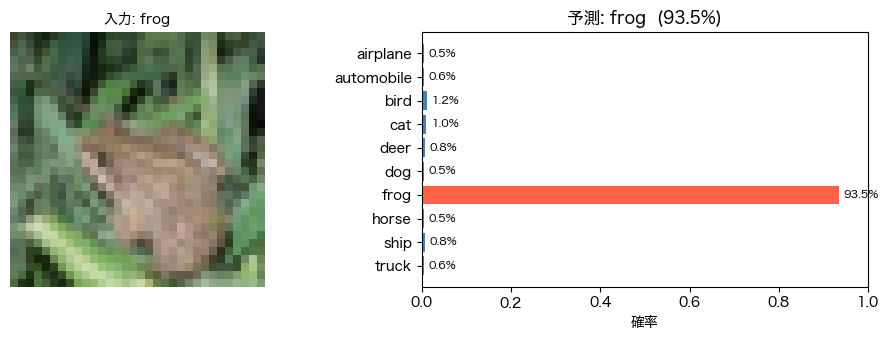

In [8]:
with torch.no_grad():
    x_normed  = model.norm(x)         # LayerNorm
    cls_vec   = x_normed[0, 0]        # (256,)  ← CLS トークン
    logits    = model.head(cls_vec)   # (10,)
    probs     = torch.softmax(logits, dim=-1)

pred = probs.argmax().item()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

show_image(img, ax=axes[0], title="入力: frog")

colors = ["tomato" if i == pred else "steelblue" for i in range(10)]
bars = axes[1].barh(CIFAR10_CLASSES, probs.numpy(), color=colors)
axes[1].set_xlabel("確率")
axes[1].set_xlim(0, 1)
axes[1].set_title(f"予測: {CIFAR10_CLASSES[pred]}  ({probs[pred]*100:.1f}%)")
axes[1].invert_yaxis()
# 各バーに確率を表示
for bar, p in zip(bars, probs):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{p*100:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()
